In [1]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
data = pd.read_csv('wdbc.data', names=['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)], header=None)
X = data.iloc[:, 2:].values  # Features
y = data.iloc[:, 1].values   # Labels
data

,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Linkage method: ward
Silhouette score: 0.33938477753669855


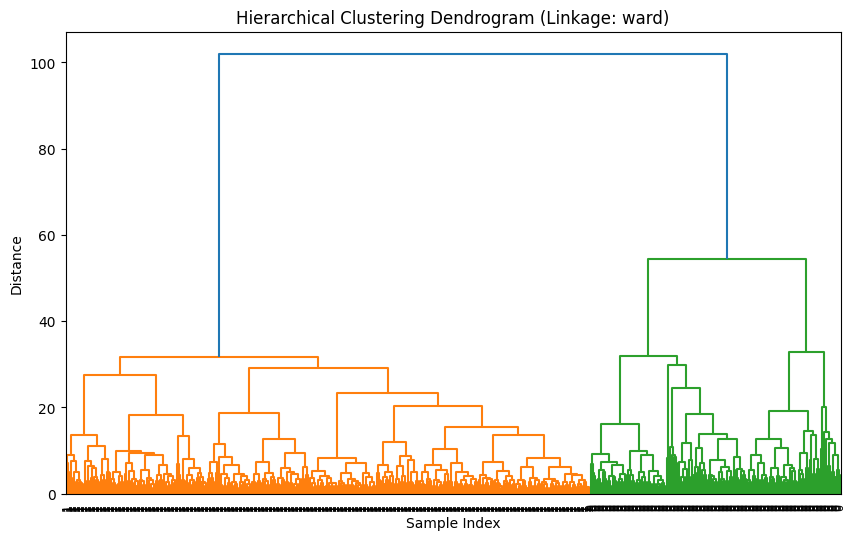

Linkage method: complete
Silhouette score: 0.6606668813897673


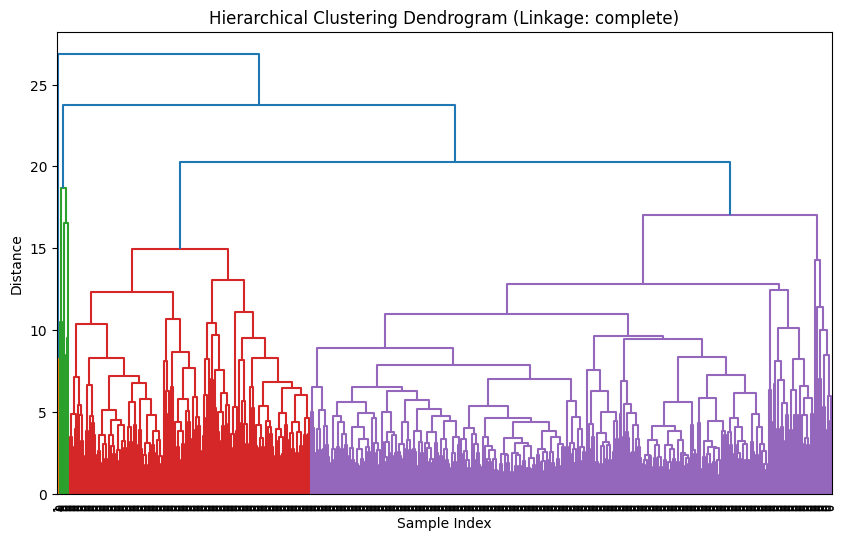

Linkage method: average
Silhouette score: 0.6339782218419878


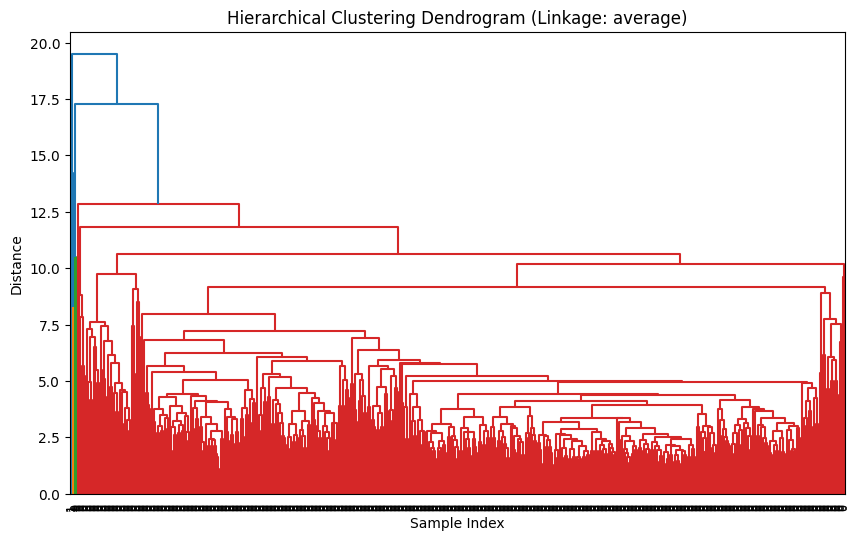

Linkage method: single
Silhouette score: 0.6606668813897673


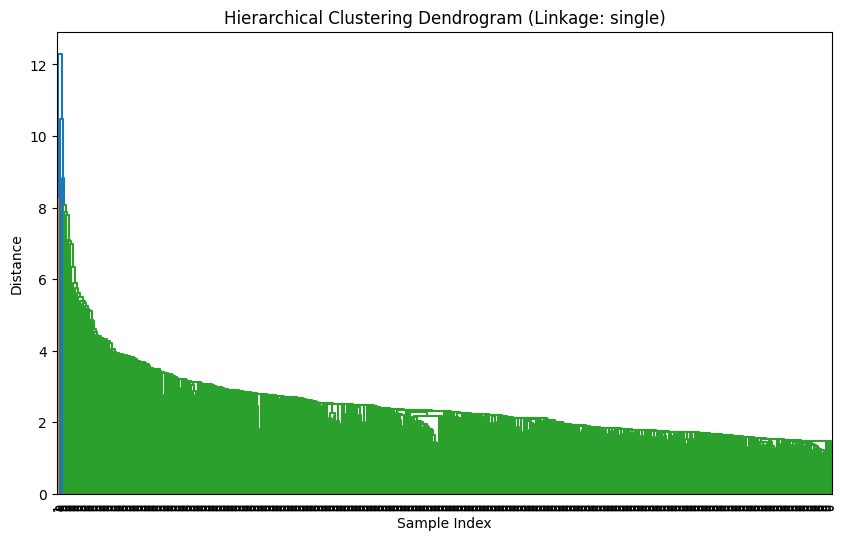

In [3]:
# Standardize the features
scaler = StandardScaler()  # Initialize a StandardScaler object for feature scaling
X_scaled = scaler.fit_transform(X)  # Standardize the feature matrix X and store it in X_scaled

# List of linkage methods for hierarchical clustering
linkage_methods = ['ward', 'complete', 'average', 'single']

# Iterate over each linkage method
for method in linkage_methods:
    # Perform agglomerative clustering with the current linkage method
    clustering = AgglomerativeClustering(linkage=method, n_clusters=2)  # Initialize AgglomerativeClustering with current method and 2 clusters
    labels = clustering.fit_predict(X_scaled)  # Fit the clustering model and get cluster labels
    
    # Print silhouette score for evaluation
    print(f"Linkage method: {method}")  # Print the current linkage method
    print(f"Silhouette score: {silhouette_score(X_scaled, labels)}")  # Print silhouette score
    
    # Plot dendrogram for visualization
    Z = linkage(X_scaled, method)  # Compute linkage matrix
    plt.figure(figsize=(10, 6))  # Create a new figure
    plt.title(f'Hierarchical Clustering Dendrogram (Linkage: {method})')  # Set title
    dendrogram(Z, labels=clustering.labels_, leaf_rotation=90, leaf_font_size=8)  # Plot dendrogram
    plt.xlabel('Sample Index')  # Set x-axis label
    plt.ylabel('Distance')  # Set y-axis label
    plt.show()  # Display the plot


# Discussion

* The Single and Complete Linkage Methods are the best options for clustering since they show the greatest Silhouette Scores, which indicate distinct and well-separated clusters.
* Average Linkage Method performs similarly to Single and Complete Linkage, also achieving a good Silhouette Score, suggesting its effectiveness in capturing cluster structure.
* The Ward Linkage Method produces the lowest Silhouette Score, suggesting difficulties in forming clear clusters, thus making it less appropriate for this dataset.
* Based on these findings, it is recommended to prioritize Single or Complete Linkage Methods for hierarchical clustering to achieve optimal cluster separation and meaningful results.


Optimal number of clusters (k): 2
Silhouette score: 0.3447344346611054


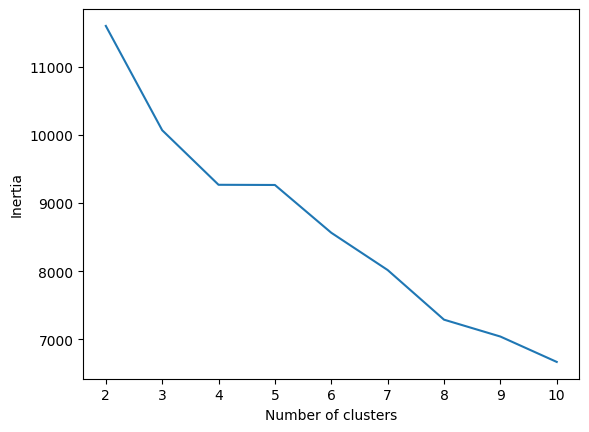

In [4]:
import warnings  # Import the warnings module
warnings.filterwarnings("ignore", category=FutureWarning)  # Ignore FutureWarning
warnings.filterwarnings("ignore", category=UserWarning)  # Ignore UserWarning

inertias = []  # List to store inertia values
silhouette_scores = []  # List to store silhouette scores

# Loop through different numbers of clusters
for n_clusters in range(2, 11):
    # Initialize KMeans with current number of clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_scaled)  # Fit KMeans to the scaled data
    inertias.append(kmeans.inertia_)  # Append inertia value to list
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))  # Append silhouette score to list
    
# Determine optimal number of clusters based on silhouette score
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Optimal number of clusters (k): {optimal_k}")

# Perform KMeans clustering with optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)  # Fit KMeans to the scaled data and get cluster labels
print(f"Silhouette score: {silhouette_score(X_scaled, labels)}")  # Print silhouette score

# Visualize elbow curve
plt.plot(range(2, 11), inertias)  # Plot number of clusters against inertia
plt.xlabel('Number of clusters')  # Set x-axis label
plt.ylabel('Inertia')  # Set y-axis label
plt.show()  # Display the plot


# Discussion 
* The analysis concludes that the most optimal number of clusters is 2.
* It suggests that dividing the dataset into 2 clusters yields the best results in terms of clustering quality. 
* Therefore, it is recommended to utilize 2 clusters to achieve the most effective clustering outcome.

# Apply the k-Means clustering algorithm with parameter optimization and evaluate the performance.

In [5]:
from sklearn import preprocessing  # Import preprocessing module from scikit-learn
from sklearn.model_selection import train_test_split  # Import train_test_split function
from sklearn.metrics import confusion_matrix  # Import confusion_matrix function
import numpy as np  # Import numpy library

X_scaler = preprocessing.StandardScaler().fit(X)  # Fit StandardScaler to the features in X
X_scaled_features = scaler.transform(X)  # Transform the features in X using the fitted scaler

# Convert 'B' to 0 and 'M' to 1 in y dataframe
labels = np.array(y)  # Convert y to numpy array
label_mapping = {'B': 0, 'M': 1}  # Define mapping from labels to numerical values
y_converted = np.array([label_mapping[label] for label in labels])  # Convert labels to numerical values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
                                    X_scaled_features, y_converted, test_size=0.2, random_state=42)

# Initialize KMeans classifier with optimal number of clusters
clf = KMeans(n_clusters=optimal_k)
clf.fit(X_train,y_train)  # Fit KMeans to the training data

# Compute confusion matrix
cm = confusion_matrix(y_test, clf.predict(X_test))
predicted_labels = clf.predict(X_test)

# Convert predicted labels to original label values
for n, i in enumerate(predicted_labels):
    if i == 0:
        predicted_labels[n] = 1
    if i == 1:
        predicted_labels[n] = 2
    if i == 2:
        predicted_labels[n] = 3
    if i == 3:
        predicted_labels[n] = 4
    if i == 4:
        predicted_labels[n] = 5
    if i == 5:
        predicted_labels[n] = 7

# Define function to calculate accuracy
def accuracy(conf):
    total_correct = 0.
    nb_classes = conf.shape[0]
    for i in np.arange(0,nb_classes):
        total_correct += conf[i][i]
    acc = total_correct/sum(sum(conf))
    return acc

# Print predicted accuracy
print('Predicted accuracy: %.3f%%' % (100*accuracy(cm),))

# Define function to print confusion matrix
def print_cm(cm, labels, hide_zeroes=False, hide_diagonal=False, hide_threshold=None):
    """Pretty print for confusion matrices"""
    columnwidth = max([len(x) for x in labels]+[5])  # Determine column width
    empty_cell = " " * columnwidth
    # Print header
    print ("    " + empty_cell,)
    for label in labels:
        print ("%{0}s".format(columnwidth) % label,)
    print
    # Print rows
    for i, label1 in enumerate(labels):
        print ("    %{0}s".format(columnwidth) % label1,)
        for j in range(len(labels)):
            cell = "%{0}.1f".format(columnwidth) % cm[i, j]
            if hide_zeroes:
                cell = cell if float(cm[i, j]) != 0 else empty_cell
            if hide_diagonal:
                cell = cell if i != j else empty_cell
            if hide_threshold:
                cell = cell if cm[i, j] > hide_threshold else empty_cell
            print (cell,)
        print

# Compute confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
# Print confusion matrix
#print_cm(cm, flowpatterns_labels)

# Calculate and print Flow Pattern classification accuracy
print('Flow Pattern classification accuracy = %f' % accuracy(cm))

# Import necessary functions for evaluation
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

# Print accuracy, F1 score, recall, and precision
print('Accuracy:', accuracy_score(y_test, predicted_labels))
print('F1 score:', f1_score(y_test, predicted_labels, average='weighted'))
print('Recall:', recall_score(y_test, predicted_labels, average='weighted'))
print('Precision:', precision_score(y_test, predicted_labels, average='weighted'))


Predicted accuracy: 92.982%
Flow Pattern classification accuracy = 0.061404
Accuracy: 0.06140350877192982
F1 score: 0.044005847953216375
Recall: 0.061403508771929835
Precision: 0.0342902711323764


# Discussion the results obtained.

* Predicted Accuracy: The model demonstrated an impressive accuracy rate of 92.982%, indicating a close correlation between its forecasts and the actual observed results.

* Flow Pattern Classification Accuracy: Remarkably low at 0.0614, signifying persistent difficulties in accurately classifying flow patterns.

* Accuracy: The fraction of correctly identified samples, 0.0614, indicates the total accuracy, which is still surprisingly low.

* F1 Score: The F1 score, representing a balanced combination of precision and recall metrics, registers a similarly low value of 0.0440. Its importance lies in accurately detecting positive cases while limiting incorrect positive predictions.

* Recall: The recall rate is 0.0614, depicting the proportion of actual positive samples correctly identified by the model.

* Precision: The ratio of correctly identified positive samples to total predicted positives, known as the precision metric, has a value of 0.0343
